# Matplotlib fundamentals

In [2]:
import pandas as pd

df = pd.read_csv("norway_new_car_sales_by_make.csv")
df.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [3]:
df.shape # rader, kolumner

(4377, 5)

In [4]:
df.info() # se kolumnerna och datatyperna i dom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4377 entries, 0 to 4376
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      4377 non-null   int64  
 1   Month     4377 non-null   int64  
 2   Make      4367 non-null   object 
 3   Quantity  4377 non-null   int64  
 4   Pct       4377 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 171.1+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,4377.0,2011.421065,2.906408,2007.0,2009.0,2011.0,2014.0,2017.0
Month,4377.0,6.459904,3.446815,1.0,3.0,6.0,9.0,12.0
Quantity,4377.0,307.802148,411.315021,1.0,14.0,153.0,461.0,3017.0
Pct,4377.0,2.762257,3.635185,0.0,0.1,1.4,4.2,22.7


In [6]:
df.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [7]:
import duckdb

df_quantity_brand = duckdb.query("""
    SELECT make AS Brand, 
           SUM(quantity) AS Quantity
    FROM df
    GROUP BY 
        make
    ORDER BY 
        Quantity
    DESC
    
""").df()

df_quantity_brand.head()

,Brand,Quantity
0,Volkswagen,206669.0
1,Toyota,168177.0
2,Volvo,99937.0
3,Ford,99713.0
4,BMW,73315.0


## Barchart

<Axes: xlabel='Brand'>

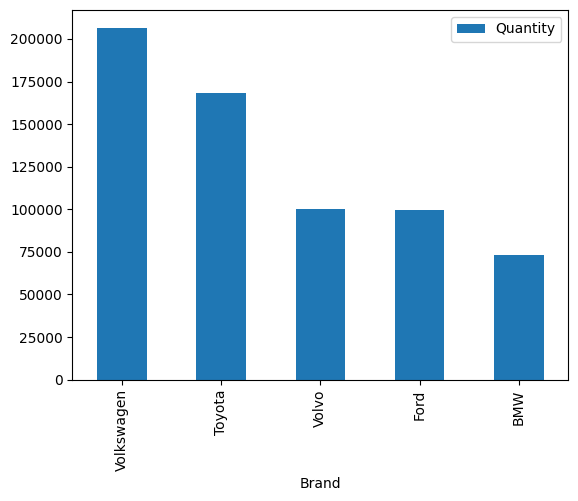

In [8]:
df_quantity_brand.head().plot(kind="bar", x="Brand", y="Quantity") # .plot() är pandas

### Plot top 5 most popular brands

<Axes: xlabel='Brand'>

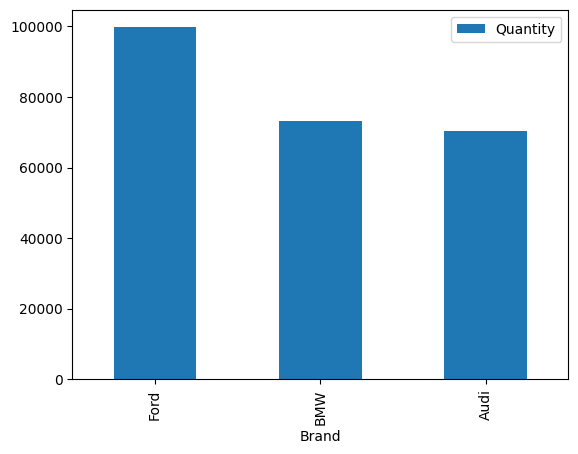

In [ ]:
df_quantity_brand.iloc[3:6].plot(kind="bar", x="Brand", y="Quantity") # Slicingen tar inte fram top 5, i detta fall

## Matplotlib bar

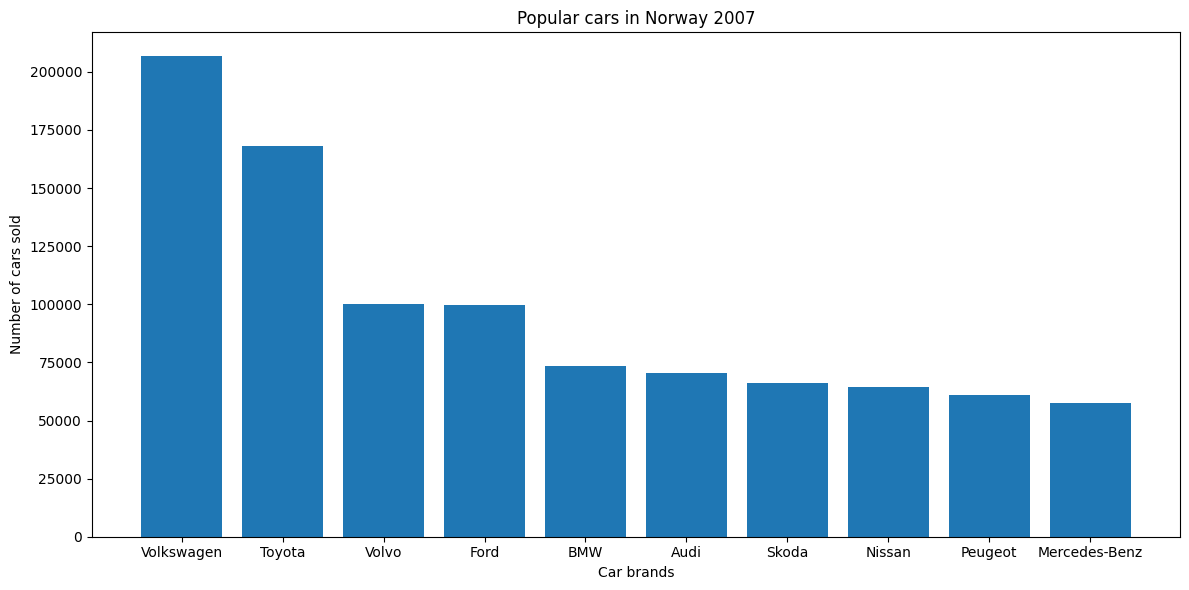

In [12]:
import matplotlib.pyplot as plt

df_quantity_brand_top10 = df_quantity_brand.iloc[:10]

fig, ax = plt.subplots(figsize = (12,6)) # figsize ((width, height)är inches) bestämmer storleken

ax.bar( # ax.bar bestäämer VAD de från df som ska visas
    x= df_quantity_brand_top10["Brand"],
    height= df_quantity_brand_top10["Quantity"],
    width=0.8
)

ax.set( # ax.set är mer info om de olika axlarna t.ex
    title= "Popular cars in Norway 2007", 
    xlabel= "Car brands", 
    ylabel= "Number of cars sold")



fig.tight_layout()
fig.savefig("figures/bars_top_10_cars.png")

## Line chart

In [ ]:
df_quantity_year = duckdb.query(""" 
    SELECT 
        year,
        SUM(quantity) AS Quantity
    FROM 
        df
    GROUP BY 
        year
    ORDER BY
        year
""").df().set_index("Year") # set_index absolut nödvändigt för att plotta året mot quantity, annars blir year en egen linje bara

In [28]:
df_quantity_year.tail()

,Quantity
Year,
2013,142151.0
2014,144202.0
2015,150686.0
2016,154603.0
2017,13055.0


<Axes: xlabel='Year'>

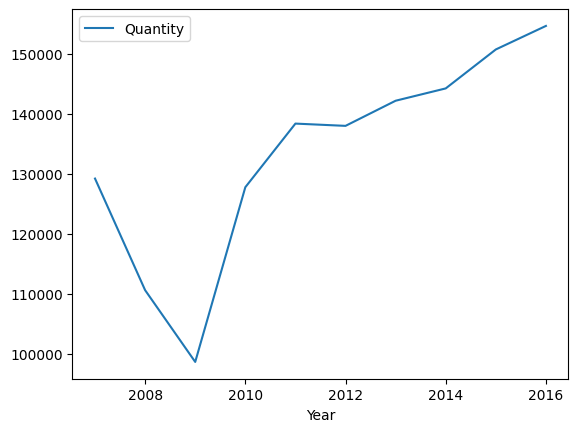

In [29]:
df_quantity_year.iloc[:-1].plot()

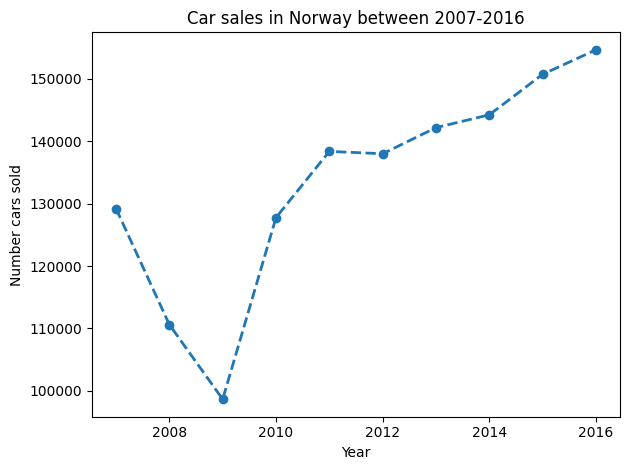

In [31]:
# OBS pandas plot
ax = df_quantity_year.iloc[:-1].plot(title="Car sales in Norway between 2007-2016", # returnerar ett ax objekt
                                xlabel= "Year", 
                                ylabel= "Number cars sold", 
                                style = "--o", 
                                linewidth = 2)

ax.legend().remove() # tar bort legend på ax objektet
fig = ax.get_figure() # skapar fig objekt
fig.tight_layout()
fig.savefig("figures/car_sales_yearly_line.png")